# 03 — Platform-Level Content Strategy Analysis

This notebook performs a comparative analysis of major streaming platforms to identify differences in **content strategy, market positioning,** and **library composition**.

The objective is to transform raw streaming content data into actionable insights by analyzing platform-level trends, identifying competitive patterns, and evaluating how different platforms differentiate themselves through their content offerings.

The analysis will focus on:

- Comparing platforms by:
  - Content volume
  - Movie vs. TV focus
  - Genre distribution
  - Release trends
  - Audience ratings (IMDb / Rotten Tomatoes, if available)
- Creating visualizations using pivot tables, stacked bars, grouped bars, and heatmaps
- Identifying patterns in content strategy and competitive positioning

**Datasets used**
- `MoviesOnStreamingPlatforms_Cleaned.csv`
- `TVShowsOnStreamingPlatforms_Cleaned.csv`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 120)

In [2]:
# Load cleaned datasets
DATA_DIR = Path("/Users/veronicahuang/Desktop/streaming-bi-template/Data")

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

movies = pd.read_csv(MOVIES_PATH)
tv = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:", tv.shape)

movies.head(3)

Movies shape: (9515, 19)
TV shape: (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,THE IRISHMAN
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,DANGAL
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,DAVID ATTENBOROUGH: A LIFE ON OUR PLANET


In [4]:
movies.columns

Index(['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre',
       'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key'],
      dtype='str')

In [5]:
# Combine into one content table (movies + tv)
movies2 = movies.copy()
tv2 = tv.copy()

df = pd.concat([movies2, tv2], ignore_index=True)

# Basic sanity checks
df[["Title", "Year", "Type", "Netflix", "Hulu", "Prime Video", "Disney+", "Type"]].head()

,Title,Year,Type,Netflix,Hulu,Prime Video,Disney+,Type
0,The Irishman,2019,movie,1,0,0,0,movie
1,Dangal,2016,movie,1,0,0,0,movie
2,David Attenborough: A Life on Our Planet,2020,movie,1,0,0,0,movie
3,Lagaan: Once Upon a Time in India,2001,movie,1,0,0,0,movie
4,Roma,2018,movie,1,0,0,0,movie


In [7]:
platform_cols = ["Netflix", "Hulu", "Prime Video", "Disney+"]

def to_long_platform(df_in: pd.DataFrame) -> pd.DataFrame:
    base_cols = [c for c in df_in.columns if c not in platform_cols]

    # Melt platform indicator columns into rows
    melted = df_in.melt(
        id_vars=base_cols,
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )

    # Keep only records where on_platform == 1
    long_df = melted[melted["on_platform"] == 1].drop(columns=["on_platform"])
    return long_df

df_long = to_long_platform(df)

print("Original rows:", len(df))
print("Long rows (one per platform):", len(df_long))
df_long[["Title", "Year", "Type", "platform", "Genre", "IMDb", "RottenTomatoes_Score"]].head()

Original rows: 14883
Long rows (one per platform): 15551


,Title,Year,Type,platform,Genre,IMDb,RottenTomatoes_Score
0,The Irishman,2019,movie,Netflix,"Biography, Crime, Drama",7.8,98.0
1,Dangal,2016,movie,Netflix,"Action, Biography, Drama",8.3,97.0
2,David Attenborough: A Life on Our Planet,2020,movie,Netflix,"Documentary, Biography",8.9,95.0
3,Lagaan: Once Upon a Time in India,2001,movie,Netflix,"Drama, Musical, Sport",8.1,94.0
4,Roma,2018,movie,Netflix,Drama,7.6,94.0


## Platform Analysis (Hulu)

In [8]:
PLATFORM = "Hulu"
platform_df = df_long[df_long["platform"] == PLATFORM].copy()

print("Platform:", PLATFORM)
print("Rows:", platform_df.shape)
platform_df.head(3)

Platform: Hulu
Rows: (2668, 16)


,ID,Title,Year,Age,Rotten Tomatoes,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key,platform
14963,81,The Social Network,2010,13+,84/100,movie,"Biography, Drama",United States,"English, French",7.8,tt1285016,84.0,13.0,0,THE SOCIAL NETWORK,Hulu
14990,108,Hey Arnold! The Jungle Movie,2017,7+,83/100,movie,drama film,United States,English,7.0,tt0245844,83.0,7.0,0,HEY ARNOLD! THE JUNGLE MOVIE,Hulu
15050,168,Hunt for the Wilderpeople,2016,13+,80/100,movie,"Adventure, Comedy, Drama",New Zealand,English,7.8,tt4698684,80.0,13.0,0,HUNT FOR THE WILDERPEOPLE,Hulu


## 1) Movie vs TV focus

In [9]:
type_counts = platform_df["Type"].value_counts()

type_counts

Type
tv_show    1621
movie      1047
Name: count, dtype: int64

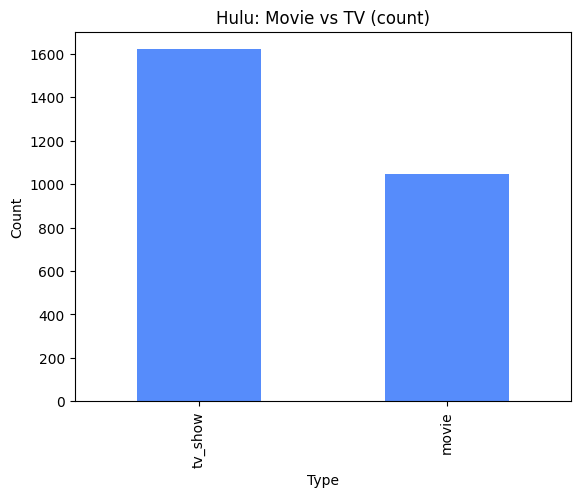

In [10]:
type_counts.plot(kind="bar")
plt.title(f"{PLATFORM}: Movie vs TV (count)")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()


## 2) Genre mix (Top 10)

In [11]:
def top_genres(df_in: pd.DataFrame, top_n: int = 10) -> pd.Series:
    g = df_in["Genre"].dropna().astype(str)
    # split on comma; if no comma, this still returns a single-item list
    exploded = g.str.split(",").explode().str.strip()
    exploded = exploded[exploded != ""]
    return exploded.value_counts().head(top_n)

genre_top = top_genres(platform_df, top_n=10)
genre_top

Genre
reality television                984
drama film                        552
drama television series           150
comedy film                       136
action film                       108
documentary film                  107
thriller film                      96
comedy drama                       90
horror film                        90
LGBT-related television series     77
Name: count, dtype: int64

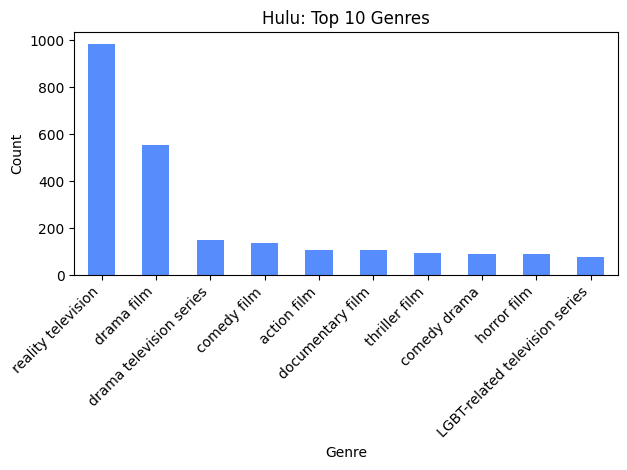

In [12]:
genre_top.plot(kind="bar")
plt.title(f"{PLATFORM}: Top 10 Genres")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



## 3) Age Rating Distribution


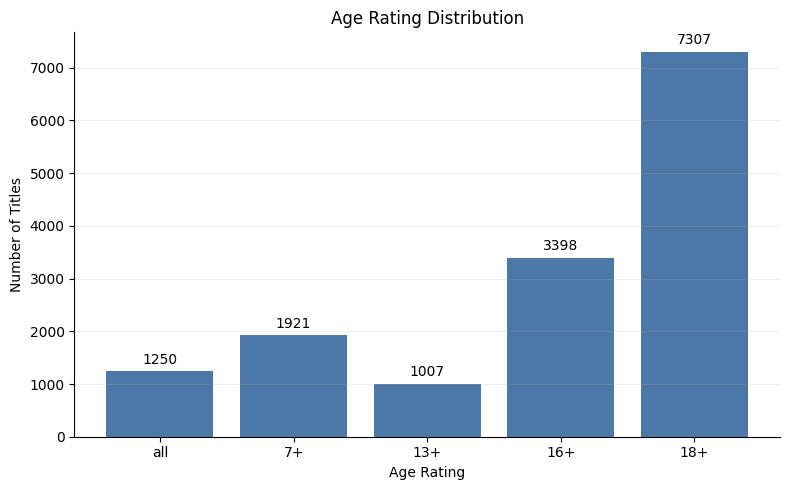

In [13]:

if 'movies' not in globals():
    movies = pd.read_csv(MOVIES_PATH)
if 'tv' not in globals():
    tv = pd.read_csv(TV_PATH)
if 'df' not in globals():
    df = pd.concat([movies, tv], ignore_index=True)

age_order = ['all', '7+', '13+', '16+', '18+']
age_counts = df['Age'].dropna().astype(str).str.strip().value_counts()
ordered_ages = [age for age in age_order if age in age_counts.index]
ordered_ages += [age for age in age_counts.index if age not in ordered_ages]
age_counts = age_counts.loc[ordered_ages]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(age_counts.index, age_counts.values, color='#4C78A8')

ax.bar_label(bars, padding=3)
ax.set_title('Age Rating Distribution')
ax.set_xlabel('Age Rating')
ax.set_ylabel('Number of Titles')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## 4) Release Year Patterns


In [14]:
platform_df["Year"] = pd.to_numeric(platform_df["Year"], errors="coerce")

platform_df["Year"].describe()

count    2668.000000
mean     2011.005997
std        11.080608
min      1923.000000
25%      2009.000000
50%      2014.000000
75%      2018.000000
max      2021.000000
Name: Year, dtype: float64

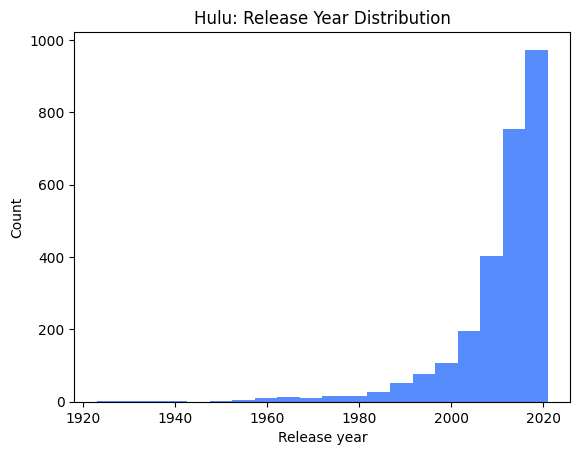

In [15]:
platform_df["Year"].dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Release Year Distribution")
plt.xlabel("Release year")
plt.ylabel("Count")
plt.show()

## 5) Score distributions (IMDb / Rotten Tomatoes)

IMDb non-null: 2092


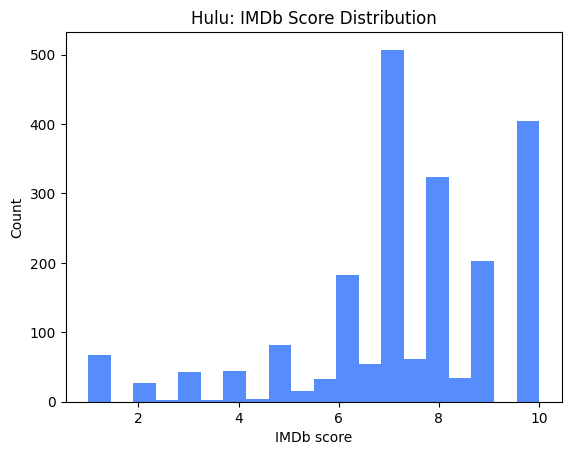

RottenTomatoes_Score non-null: 2668


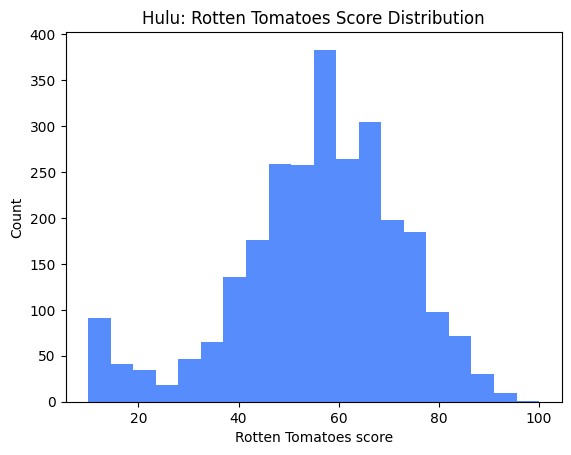

In [16]:
# IMDb distribution
imdb = pd.to_numeric(platform_df["IMDb"], errors="coerce")
print("IMDb non-null:", imdb.notna().sum())

imdb.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: IMDb Score Distribution")
plt.xlabel("IMDb score")
plt.ylabel("Count")
plt.show()

# Rotten Tomatoes distribution
rt = pd.to_numeric(platform_df["RottenTomatoes_Score"], errors="coerce")
print("RottenTomatoes_Score non-null:", rt.notna().sum())

rt.dropna().plot(kind="hist", bins=20)
plt.title(f"{PLATFORM}: Rotten Tomatoes Score Distribution")
plt.xlabel("Rotten Tomatoes score")
plt.ylabel("Count")
plt.show()


## 6) Analysis of Hulu's Content Identity


Based on the age rating distribution, genre mix, and the release year distribution, Hulu appears
to focus on modern, mature-oriented television content. The platform’s catalog is characterized
by a strong emphasis on reality television and drama, with TV-related genres dominating over
movies. Moreover, the release year chart suggests that Hulu primarily offers recent content, with
the majority of titles released after 2010, indicating a stronger focus on newer releases rather
than legacy content. The age rating distribution shows that 18+ content makes up the largest
portion of the catalog, followed by 16+, suggesting that Hulu primarily targets adult viewers,
while family-friendly content is less common. Overall, Hulu’s content identity can be described
as a streaming platform centered on recent, adult-oriented TV content, especially reality and
drama programming.

## Multi-Platform Market Comparison

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Make plots larger and readable in class
plt.rcParams['figure.figsize'] = (12, 6)

DATA_DIR = Path("/Users/veronicahuang/Desktop/streaming-bi-template/Data")

MOVIES_PATH = DATA_DIR / "MoviesOnStreamingPlatforms_Cleaned.csv"
TV_PATH     = DATA_DIR / "TVShowsOnStreamingPlatforms_Cleaned.csv"

print('Movies file:', MOVIES_PATH)
print('TV file:    ', TV_PATH)

Movies file: /Users/veronicahuang/Desktop/streaming-bi-template/Data/MoviesOnStreamingPlatforms_Cleaned.csv
TV file:     /Users/veronicahuang/Desktop/streaming-bi-template/Data/TVShowsOnStreamingPlatforms_Cleaned.csv


In [18]:
movies = pd.read_csv(MOVIES_PATH)
tv     = pd.read_csv(TV_PATH)

print("Movies shape:", movies.shape)
print("TV shape:    ", tv.shape)

display(movies.head())

Movies shape: (9515, 19)
TV shape:     (5368, 19)


,ID,Title,Year,Age,Rotten Tomatoes,Netflix,Hulu,Prime Video,Disney+,Type,Genre,Country,Language,IMDb,IMDb_ID,RottenTomatoes_Score,Age_Min,Type_raw,Title_key
0,1,The Irishman,2019,18+,98/100,1,0,0,0,movie,"Biography, Crime, Drama",United States,"English, Italian, Latin, Spanish, German",7.8,tt1302006,98.0,18.0,0,THE IRISHMAN
1,2,Dangal,2016,7+,97/100,1,0,0,0,movie,"Action, Biography, Drama","India, United States","Hindi, English",8.3,tt5074352,97.0,7.0,0,DANGAL
2,3,David Attenborough: A Life on Our Planet,2020,7+,95/100,1,0,0,0,movie,"Documentary, Biography",United Kingdom,English,8.9,tt11989890,95.0,7.0,0,DAVID ATTENBOROUGH: A LIFE ON OUR PLANET
3,4,Lagaan: Once Upon a Time in India,2001,7+,94/100,1,0,0,0,movie,"Drama, Musical, Sport","India, United States","Hindi, English",8.1,tt0169102,94.0,7.0,0,LAGAAN: ONCE UPON A TIME IN INDIA
4,5,Roma,2018,18+,94/100,1,0,0,0,movie,Drama,"Mexico, United States","Spanish, Mixtec, English, Japanese, German, Fr...",7.6,tt6155172,94.0,18.0,0,ROMA



## 1) Quick Data Audit (Columns + Missingness)

In [19]:

def summarize_df(df, name):
    print(f"\n==== {name} ====")
    print("Columns:", list(df.columns))
    print("\nMissingness (top 15):")
    display(df.isna().mean().sort_values(ascending=False).head(15))
    print("\nDtypes (top 15):")
    display(df.dtypes.head(15))


summarize_df(movies, "Movies")
summarize_df(tv, "TV Shows")


==== Movies ====
Columns: ['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre', 'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key']

Missingness (top 15):


ID                      0.0
Genre                   0.0
Type_raw                0.0
Age_Min                 0.0
RottenTomatoes_Score    0.0
IMDb_ID                 0.0
IMDb                    0.0
Language                0.0
Country                 0.0
Type                    0.0
Title                   0.0
Disney+                 0.0
Prime Video             0.0
Hulu                    0.0
Netflix                 0.0
dtype: float64


Dtypes (top 15):


ID                   int64
Title                  str
Year                 int64
Age                    str
Rotten Tomatoes        str
Netflix              int64
Hulu                 int64
Prime Video          int64
Disney+              int64
Type                   str
Genre                  str
Country                str
Language               str
IMDb               float64
IMDb_ID                str
dtype: object


==== TV Shows ====
Columns: ['ID', 'Title', 'Year', 'Age', 'Rotten Tomatoes', 'Netflix', 'Hulu', 'Prime Video', 'Disney+', 'Type', 'Genre', 'Country', 'Language', 'IMDb', 'IMDb_ID', 'RottenTomatoes_Score', 'Age_Min', 'Type_raw', 'Title_key']

Missingness (top 15):


ID                      0.0
Genre                   0.0
Type_raw                0.0
Age_Min                 0.0
RottenTomatoes_Score    0.0
IMDb_ID                 0.0
IMDb                    0.0
Language                0.0
Country                 0.0
Type                    0.0
Title                   0.0
Disney+                 0.0
Prime Video             0.0
Hulu                    0.0
Netflix                 0.0
dtype: float64


Dtypes (top 15):


ID                 int64
Title                str
Year               int64
Age                  str
Rotten Tomatoes      str
Netflix            int64
Hulu               int64
Prime Video        int64
Disney+            int64
Type                 str
Genre                str
Country              str
Language             str
IMDb                 str
IMDb_ID              str
dtype: object


## 2) Standardize Schema


In [20]:

# --- Helpers ---

PLATFORMS = [
    "Netflix", "Hulu", "Prime Video", "Disney+"
]


def melt_binary_platforms(df, platform_cols):
    # Expect platform columns are 0/1 or True/False
    tmp = df.copy()
    for c in platform_cols:
        tmp[c] = tmp[c].fillna(0)
    long = tmp.melt(
        id_vars=[c for c in tmp.columns if c not in platform_cols],
        value_vars=platform_cols,
        var_name="platform",
        value_name="on_platform"
    )
    long = long[long["on_platform"].astype(int) == 1].drop(columns=["on_platform"])
    return long


def standardize_common_fields(df):
    out = df.copy()

    # title
    if "title" not in out.columns:
        for cand in ["Title", "name", "Name"]:
            if cand in out.columns:
                out = out.rename(columns={cand: "title"})
                break

    # year
    if "year" not in out.columns:
        for cand in ["Year", "release_year", "Release Year", "released", "Release_Year"]:
            if cand in out.columns:
                out = out.rename(columns={cand: "year"})
                break

    # genre
    if "genre" not in out.columns:
        for cand in ["Genre", "genres", "listed_in", "Listed In", "category"]:
            if cand in out.columns:
                out = out.rename(columns={cand: "genre"})
                break

    # clean year
    if "year" in out.columns:
        out["year"] = pd.to_numeric(out["year"], errors="coerce").astype("Int64")

    # clean genre: keep only the first genre if comma-separated
    if "genre" in out.columns:
        out["genre"] = out["genre"].astype(str).str.strip()
        out["genre"] = out["genre"].replace({"nan": np.nan})
        out["genre_primary"] = out["genre"].str.split(",").str[0].str.strip()
    else:
        out["genre_primary"] = np.nan

    # Rotten Tomatoes Score
    if "RottenTomatoes_Score" in out.columns:
        out["rotten_tomatoes_score"] = out["RottenTomatoes_Score"]

    return out


def standardize_to_long(df, content_type):
    df = standardize_common_fields(df)

    out = melt_binary_platforms(df, PLATFORMS)

    out["platform"] = out["platform"].astype(str).str.strip()

    out["type"] = content_type

    # Minimal required columns
    keep = []
    for c in ["title", "type", "platform", "year", "genre_primary", "rotten_tomatoes_score"]:
        if c in out.columns:
            keep.append(c)
    out = out[keep].copy()

    # Standardize column names
    if "genre_primary" in out.columns:
        out = out.rename(columns={"genre_primary": "genre"})
    else:
        out["genre"] = np.nan

    return out


movies_long = standardize_to_long(movies, "Movie")
tv_long = standardize_to_long(tv, "TV Show")

df = pd.concat([movies_long, tv_long], ignore_index=True)

print("Unified df shape:", df.shape)
display(df.head())


Unified df shape: (15551, 6)


,title,type,platform,year,genre,rotten_tomatoes_score
0,The Irishman,Movie,Netflix,2019,Biography,98.0
1,Dangal,Movie,Netflix,2016,Action,97.0
2,David Attenborough: A Life on Our Planet,Movie,Netflix,2020,Documentary,95.0
3,Lagaan: Once Upon a Time in India,Movie,Netflix,2001,Drama,94.0
4,Roma,Movie,Netflix,2018,Drama,94.0


## 3) Basic Quality Checks

In [21]:
# Missingness
display(df.isna().mean().sort_values(ascending=False))

# Duplicates (title + platform + type)
dup_mask = df.duplicated(subset=["title", "platform", "type"], keep=False)
dups = df[dup_mask].sort_values(["title", "platform", "type"])
print("Duplicate rows:", dups.shape[0])
display(dups.head(10))

title                    0.0
type                     0.0
platform                 0.0
year                     0.0
genre                    0.0
rotten_tomatoes_score    0.0
dtype: float64

Duplicate rows: 0


,title,type,platform,year,genre,rotten_tomatoes_score


## 4) Pivot Tables for Market Comparison
These pivots are the *foundation* for all charts.

### A) Total content count by platform


In [22]:
pivot_total = df.pivot_table(
    index="platform",
    values="title",
    aggfunc="count"
).rename(columns={"title": "title_count"}).sort_values("title_count", ascending=False)

display(pivot_total)

,title_count
platform,
Prime Video,5944
Netflix,5666
Hulu,2668
Disney+,1273


### B) Content count by platform and type (Movie vs TV)

In [23]:
pivot_type = df.pivot_table(
    index="platform",
    columns="type",
    values="title",
    aggfunc="count",
    fill_value=0
).sort_values(by=list(df["type"].dropna().unique()), ascending=False)

display(pivot_type)


type,Movie,TV Show
platform,,
Prime Video,4113,1831
Netflix,3695,1971
Hulu,1047,1621
Disney+,922,351


### C) Genre mix by platform (Top genres)

In [24]:

# Determine top N genres globally
TOP_N = 10
top_genres = (df["genre"]
              .dropna()
              .value_counts()
              .head(TOP_N)
              .index.tolist())

df_topg = df[df["genre"].isin(top_genres)].copy()

pivot_genre = df_topg.pivot_table(
    index="platform",
    columns="genre",
    values="title",
    aggfunc="count",
    fill_value=0
)

display(pivot_genre)

genre,Comedy,action film,comedy drama,comedy film,documentary film,drama film,drama television series,horror film,reality television,romantic comedy
platform,,,,,,,,,,
Disney+,0,18,12,59,39,545,5,2,256,11
Hulu,4,57,66,80,101,390,87,48,978,44
Netflix,218,80,100,269,231,1515,94,50,1019,127
Prime Video,16,164,120,214,189,2089,81,139,1363,125



## 5) Charts
- Stacked bar: **genre composition** by platform
- Grouped bar: **volume comparison** by platform and type
- Heatmap: **release year patterns** across platforms


### 5.1 Stacked Bar — Genre Composition (Top Genres)

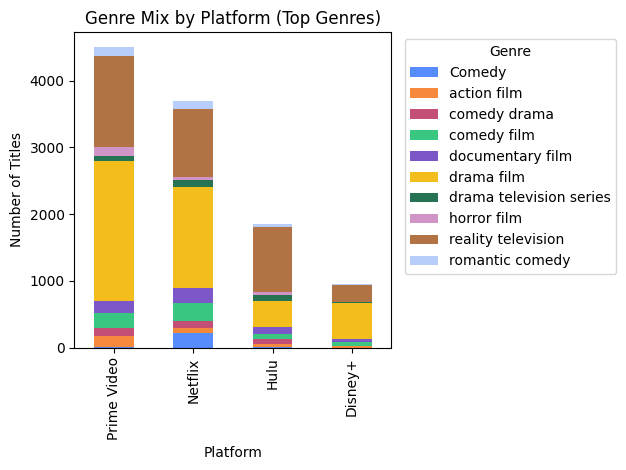

In [25]:
# Stacked bar chart from pivot table
ax = pivot_genre.loc[pivot_total.index].plot(kind="bar", stacked=True)
ax.set_title("Genre Mix by Platform (Top Genres)")
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Titles")
plt.legend(title="Genre", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### 5.2 Grouped Bar — Volume Comparison (Movies vs TV Shows)

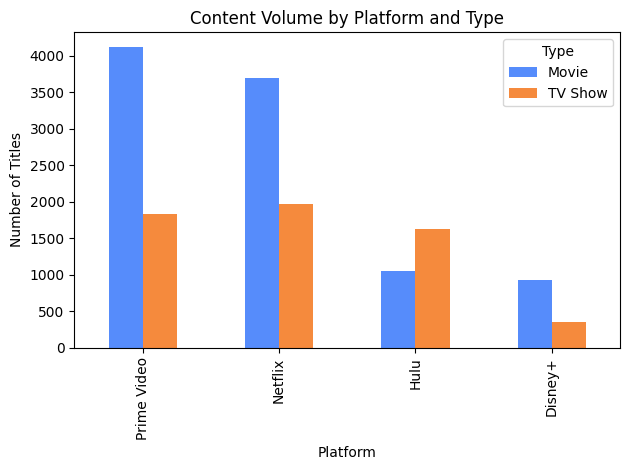

In [26]:
### 5.2 Grouped Bar — Volume Comparison (Movies vs TV Shows)
ax = pivot_type.loc[pivot_total.index].plot(kind="bar")
ax.set_title("Content Volume by Platform and Type")
ax.set_xlabel("Platform")
ax.set_ylabel("Number of Titles")
plt.legend(title="Type")
plt.tight_layout()
plt.show()


### 6.3 Heatmap — Release Year Patterns by Platform

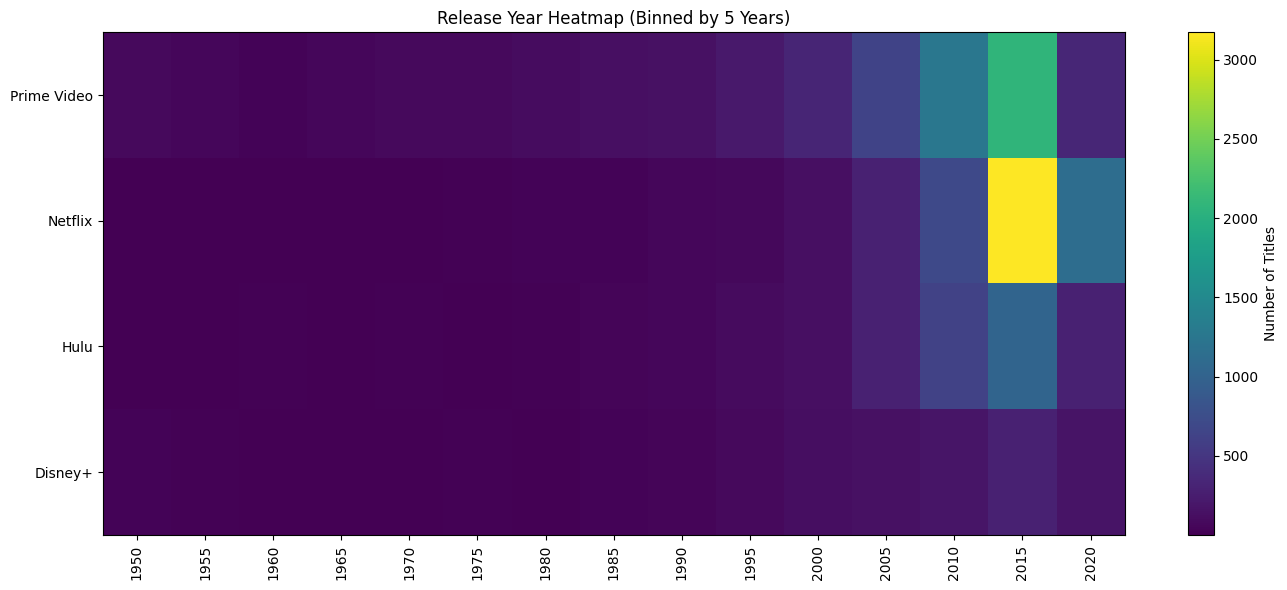

year_bin,1950,1955,1960,1965,1970,1975,1980,1985,1990,1995,2000,2005,2010,2015,2020
platform,,,,,,,,,,,,,,,
Prime Video,80,55,38,61,87,84,105,137,139,218,334,646,1255,2080,343
Netflix,2,3,6,4,9,17,34,35,57,69,132,296,697,3173,1132
Hulu,4,5,15,11,17,12,25,47,60,99,132,298,632,1018,288
Disney+,27,25,13,12,13,26,14,34,49,79,116,142,176,299,167


In [27]:
# Filter reasonable year range (optional; adjust if your data is older/newer)
df_year = df[df["year"].between(1950, 2030)].copy()

# Create year bins (e.g., 5-year buckets)
BIN_SIZE = 5
df_year["year_bin"] = (df_year["year"] // BIN_SIZE) * BIN_SIZE
df_year["year_bin"] = df_year["year_bin"].astype("Int64")

pivot_year = df_year.pivot_table(
    index="platform",
    columns="year_bin",
    values="title",
    aggfunc="count",
    fill_value=0
).loc[pivot_total.index]

# Plot heatmap using matplotlib (no seaborn)
fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot_year.values, aspect="auto")

ax.set_title(f"Release Year Heatmap (Binned by {BIN_SIZE} Years)")
ax.set_yticks(range(len(pivot_year.index)))
ax.set_yticklabels(pivot_year.index)

ax.set_xticks(range(len(pivot_year.columns)))
ax.set_xticklabels(pivot_year.columns, rotation=90)

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Number of Titles")

plt.tight_layout()
plt.show()

display(pivot_year.head())

### 6.4 Box Plot — Score Distribution by Platform

/var/folders/md/c9b0dgp518v76y7l9g2rzr9m0000gn/T/ipykernel_23947/3908649869.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=platform_order, showfliers=True)


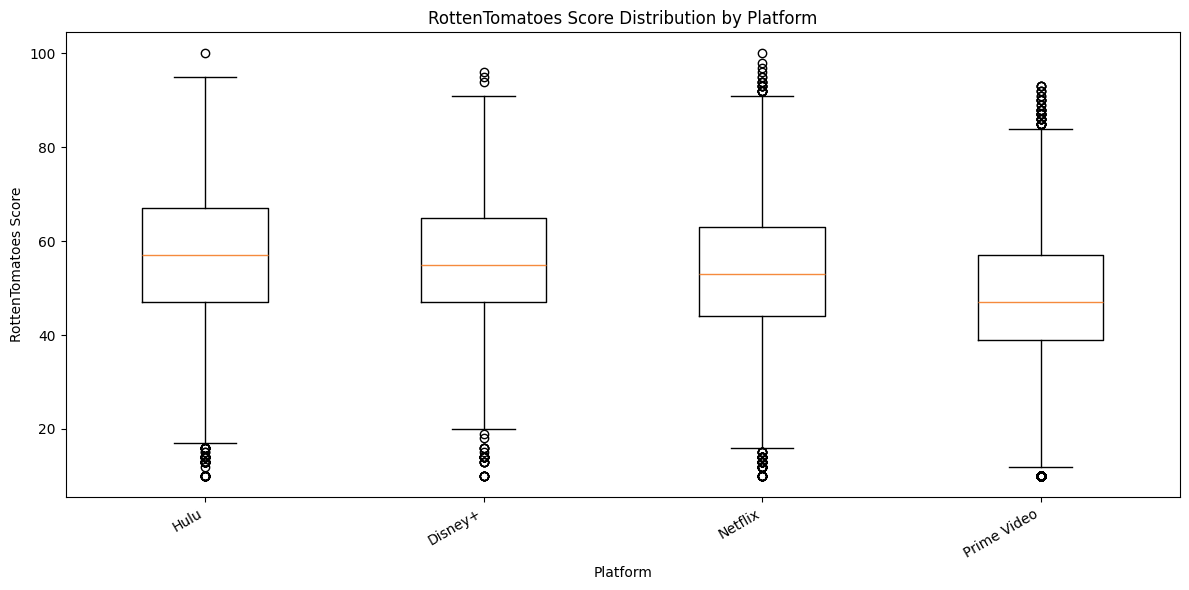

In [28]:
df_score = df.copy()
df_score["rotten_tomatoes_score"] = pd.to_numeric(df_score["rotten_tomatoes_score"], errors="coerce")

# Keep only rows with valid platform + score
df_score = df_score.dropna(subset=["platform", "rotten_tomatoes_score"])

platform_order = (
    df_score.groupby("platform")["rotten_tomatoes_score"]
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)

data = [df_score.loc[df_score["platform"] == p, "rotten_tomatoes_score"].values for p in platform_order]

plt.figure(figsize=(12, 6))
plt.boxplot(data, labels=platform_order, showfliers=True)
plt.title("RottenTomatoes Score Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("RottenTomatoes Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

### 5.5 Mean score by platform and type

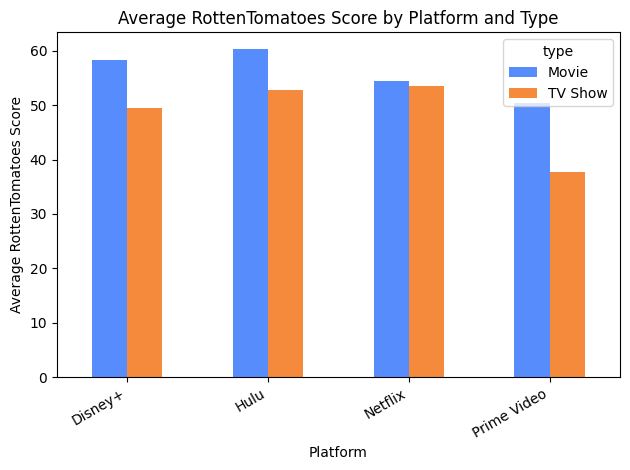

type,Movie,TV Show
platform,,
Disney+,58.312364,49.424501
Hulu,60.397326,52.837754
Netflix,54.443302,53.559107
Prime Video,50.398736,37.761333


In [29]:
summary_type = (
    df_score.groupby(["platform", "type"])["rotten_tomatoes_score"]
    .agg(["count", "mean"])
    .reset_index()
)

# Pivot for grouped bar chart
pivot_score = summary_type.pivot(index="platform", columns="type", values="mean").fillna(0)

# Order platforms by overall mean
platform_order = (
    df_score.groupby("platform")["rotten_tomatoes_score"]
    .mean()
    .sort_values(ascending=False)
    .index
)
pivot_score = pivot_score.loc[platform_order]

ax = pivot_score.plot(kind="bar")
ax.set_title("Average RottenTomatoes Score by Platform and Type")
ax.set_xlabel("Platform")
ax.set_ylabel("Average RottenTomatoes Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

display(pivot_score)